# Dataanalys

## Importera pandas

In [2]:
import pandas as pd

## Läsa in olika datafiler
Vi kan läsa in olika typer av datafiler. Sparas som en DataFrame.

In [ ]:
df = pd.read_csv("befolkningsdata.csv")

,kommun,län,år,befolkning
0,Stockholm,Stockholms län,2023,984748
1,Göteborg,Västra Götalands län,2023,592300
2,Malmö,Skåne län,2023,351749
3,Uppsala,Uppsala län,2023,239855
4,Eskilstuna,Södermanlands län,2023,108245


In [5]:
df = pd.read_excel("befolkningsdata.xlsx")

In [21]:
df = pd.read_json("befolkningsdata.json")
df

,kommun,län,år,befolkning,yta
0,Stockholm,Stockholms län,2023,-984748,188
1,Göteborg,Västra Götalands län,2023,592300,447
2,Malmö,Skåne län,2023,351749,335
3,Uppsala,Uppsala län,2023,239855,2189
4,Eskilstuna,Södermanlands län,2023,-,1250


## Utforska datan

In [17]:
df.head()  # Visar de första raderna i DataFrame


,kommun,län,år,befolkning
0,Stockholm,Stockholms län,2023,-984748
1,Göteborg,Västra Götalands län,2023,592300
2,Malmö,Skåne län,2023,351749
3,Uppsala,Uppsala län,2023,239855
4,Eskilstuna,Södermanlands län,2023,-


In [8]:
df.head()  # Visar de första raderna i DataFrame

,kommun,län,år,befolkning
0,Stockholm,Stockholms län,-2023,984748
1,Göteborg,Västra Götalands län,2023,592300
2,Malmö,Skåne län,2023,351749
3,Uppsala,Uppsala län,2023,239855
4,Eskilstuna,Södermanlands län,2023,n/a


In [9]:
df.shape # Visar antalet rader och kolumner i DataFrame

(5, 4)

In [10]:
df.columns # Visar kolumnnamnen i DataFrame


Index(['kommun', 'län', 'år', 'befolkning'], dtype='object')

Nedan ser vi att Dtype för befolkning är object istället för int64. Det indikerar att allt vi skrivit i den kolumnen inte är nummer.

In [11]:
df.info()  # Visar information om DataFrame, inklusive datatyper och null-värden

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   kommun      5 non-null      object
 1   län         5 non-null      object
 2   år          5 non-null      int64 
 3   befolkning  5 non-null      object
dtypes: int64(1), object(3)
memory usage: 292.0+ bytes


För att köra funktioner på en viss kolumn skriver vi 
df["Kolumnnamn"]

In [18]:
df["år"]  # Visar kolumnen "år" i DataFrame

0    2023
1    2023
2    2023
3    2023
4    2023
Name: år, dtype: int64

In [ ]:
df["år"].unique() # Visar unika värden i kolumnen "år"

array([2023])

## Data cleaning 
Data cleaning handlar om att behandla datan innan vi arbetar med den. Till exempel vill vi få bort alla negativa värden innan vi beräknar ett medelvärde på befolkning (vi kan ju inte ha en negativ befolkning och det påverkar vårt resultat mycket).

In [22]:
df['befolkning'] = pd.to_numeric(df['befolkning'], errors='coerce') # Konverterar kolumnen "befolkning" till numeriska värden, och ersätter icke-numeriska värden med NaN (not a number)

Exempel på hur vi kan hantera saknade värden.

In [ ]:
df.dropna()                          # ta bort rader med saknade värden
df.fillna(0)                         # ersätt med ett fast värde
df.fillna(df['befolkning'].mean())   # ersätt med medelvärdet

Vi väljer att ta bort alla NaN

In [23]:
df = df.dropna()

In [24]:
df[df['befolkning'] < 0] # Filtrerar DataFrame för att visa rader där kolumnen "befolkning" är mindre än 0

,kommun,län,år,befolkning,yta
0,Stockholm,Stockholms län,2023,-984748.0,188


Vi antar att om det finns ett negativt värde så har vi råkat få med minustecknet, det är alltså det positiva värdet som är det riktiga värdet. 

In [25]:
df['befolkning'] = df['befolkning'].abs() # Tar absolutvärdet av kolumnen "befolkning" i df_mod, vilket gör alla negativa värden positiva

C:\Users\alexa\AppData\Local\Temp\ipykernel_14388\4202556159.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['befolkning'] = df['befolkning'].abs() # Tar absolutvärdet av kolumnen "befolkning" i df_mod, vilket gör alla negativa värden positiva


In [26]:
df

,kommun,län,år,befolkning,yta
0,Stockholm,Stockholms län,2023,984748.0,188
1,Göteborg,Västra Götalands län,2023,592300.0,447
2,Malmö,Skåne län,2023,351749.0,335
3,Uppsala,Uppsala län,2023,239855.0,2189


## Använda datan
Nu när vi har städat datan kan vi använda den för olika analyser.

## Filtrering

In [26]:
df[df['kommun'] == 'Stockholm']

,kommun,län,år,befolkning
0,Stockholm,Stockholms län,2023,984748.0


In [27]:
df[df['befolkning'] > 100000]

,kommun,län,år,befolkning
0,Stockholm,Stockholms län,2023,984748.0
1,Göteborg,Västra Götalands län,2023,592300.0
2,Malmö,Skåne län,2023,351749.0
3,Uppsala,Uppsala län,2023,239855.0


## Manipulering

In [28]:
df['befolkning_tusental'] = df['befolkning'].apply(lambda x: round(x / 1000, 1))
df

C:\Users\alexa\AppData\Local\Temp\ipykernel_14752\4244110438.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['befolkning_tusental'] = df['befolkning'].apply(lambda x: round(x / 1000, 1))


,kommun,län,år,befolkning,befolkning_tusental
0,Stockholm,Stockholms län,2023,984748.0,984.7
1,Göteborg,Västra Götalands län,2023,592300.0,592.3
2,Malmö,Skåne län,2023,351749.0,351.7
3,Uppsala,Uppsala län,2023,239855.0,239.9


In [29]:
df['storlekskategori'] = df['befolkning'].apply(
    lambda x: 'Storstad' if x > 400000 else 'Mindre stad'
)
df

C:\Users\alexa\AppData\Local\Temp\ipykernel_14752\860196761.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['storlekskategori'] = df['befolkning'].apply(


,kommun,län,år,befolkning,befolkning_tusental,storlekskategori
0,Stockholm,Stockholms län,2023,984748.0,984.7,Storstad
1,Göteborg,Västra Götalands län,2023,592300.0,592.3,Storstad
2,Malmö,Skåne län,2023,351749.0,351.7,Mindre stad
3,Uppsala,Uppsala län,2023,239855.0,239.9,Mindre stad


## Groupby och aggregering

In [ ]:
df.groupby('län') # Grupperar DataFrame efter kolumnen "län"

In [ ]:
df.groupby('län')['befolkning'].sum() # Grupperar DataFrame efter kolumnen "län" och beräknar summan av kolumnen "befolkning" för varje grupp

län
Skåne län               351749.0
Stockholms län          984748.0
Uppsala län             239855.0
Västra Götalands län    592300.0
Name: befolkning, dtype: float64

In [ ]:
df.groupby('län')['befolkning'].agg(['sum', 'mean', 'max', 'count']) # 

,sum,mean,max,count
län,,,,
Skåne län,351749.0,351749.0,351749.0,1
Stockholms län,984748.0,984748.0,984748.0,1
Uppsala län,239855.0,239855.0,239855.0,1
Västra Götalands län,592300.0,592300.0,592300.0,1


In [ ]:
df.groupby(['län', 'år'])['befolkning'].sum()  # Grupperar DataFrame efter kolumnerna "län" och "år" och beräknar summan av kolumnen "befolkning" för varje grupp

län                   år  
Skåne län             2023    351749.0
Stockholms län        2023    984748.0
Uppsala län           2023    239855.0
Västra Götalands län  2023    592300.0
Name: befolkning, dtype: float64

In [36]:
df['befolkning'].describe()

count         4.000000
mean     542163.000000
std      329667.923449
min      239855.000000
25%      323775.500000
50%      472024.500000
75%      690412.000000
max      984748.000000
Name: befolkning, dtype: float64

In [37]:
print(df['befolkning'].mean())
print(df['befolkning'].median())
print(df['befolkning'].std())
print(df['befolkning'].min())
print(df['befolkning'].max())


542163.0
472024.5
329667.92344923905
239855.0
984748.0


In [38]:
df.groupby('län')['befolkning'].mean()
df.groupby('län')['befolkning'].describe()


,count,mean,std,min,25%,50%,75%,max
län,,,,,,,,
Skåne län,1.0,351749.0,NaN,351749.0,351749.0,351749.0,351749.0,351749.0
Stockholms län,1.0,984748.0,NaN,984748.0,984748.0,984748.0,984748.0,984748.0
Uppsala län,1.0,239855.0,NaN,239855.0,239855.0,239855.0,239855.0,239855.0
Västra Götalands län,1.0,592300.0,NaN,592300.0,592300.0,592300.0,592300.0,592300.0


## Matplotlib

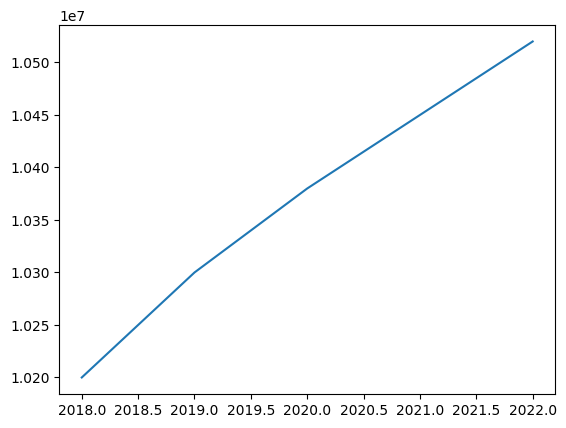

In [5]:
import matplotlib.pyplot as plt

x = [2018, 2019, 2020, 2021, 2022]
y = [10200000, 10300000, 10380000, 10450000, 10520000]

fig, ax = plt.subplots() # Skapar en figur och en axel för att rita grafen
ax.plot(x, y) # Ritar en linje med x- och y-värdena
plt.show() # Visar grafen

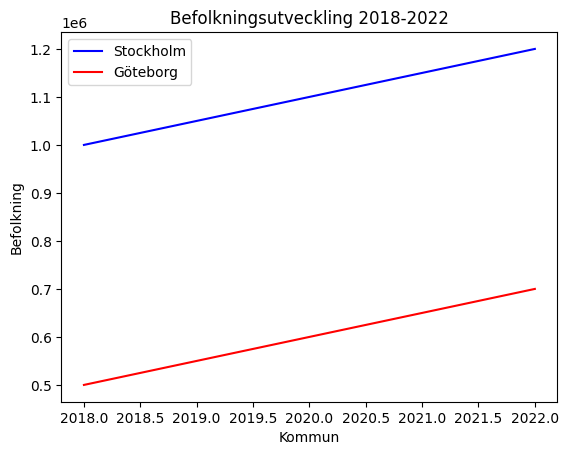

In [27]:
import matplotlib.pyplot as plt

år = [2018, 2019, 2020, 2021, 2022]
stockholm_befolkning = [1000000, 1050000, 1100000, 1150000, 1200000]
göteborg_befolkning = [500000, 550000, 600000, 650000, 700000]

fig, ax = plt.subplots()
ax.plot(år, stockholm_befolkning, label="Stockholm", color='blue')
ax.plot(år, göteborg_befolkning, label="Göteborg", color='red')
ax.legend()
plt.xlabel('Kommun')
plt.ylabel('Befolkning')
plt.title('Befolkningsutveckling 2018-2022')
plt.show()

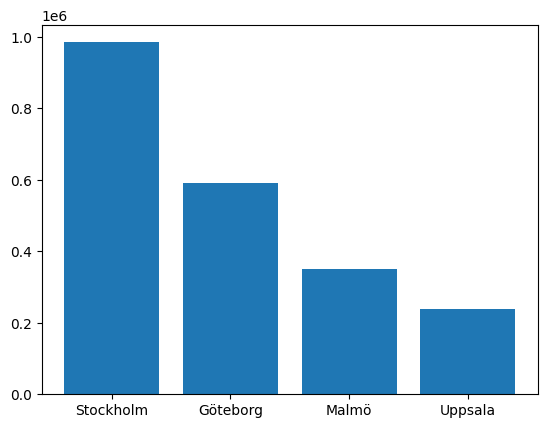

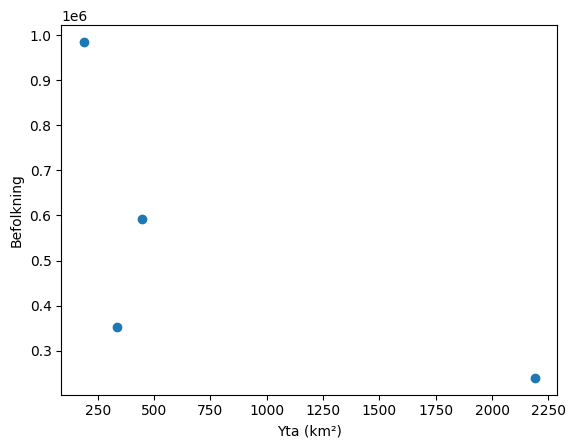

In [29]:
fig, ax = plt.subplots()
ax.bar(df['kommun'], df['befolkning'])
plt.show()

fig, ax = plt.subplots()
ax.scatter(df['yta'], df['befolkning'])
ax.set_xlabel('Yta (km²)')
ax.set_ylabel('Befolkning')
plt.show()

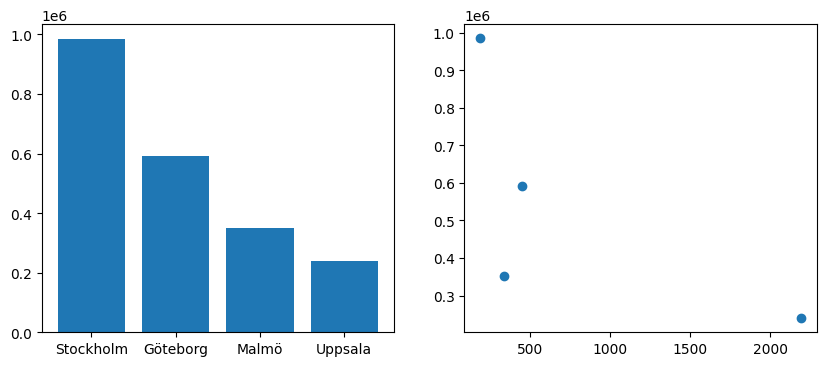

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(df['kommun'], df['befolkning'])
axs[1].scatter(df['yta'], df['befolkning'])

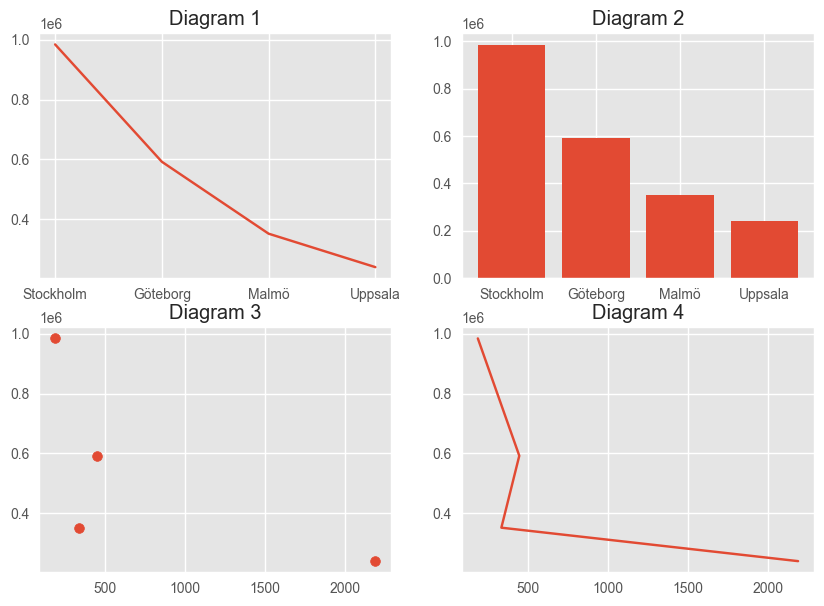

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7))

axs[0, 0].plot(df['kommun'], df['befolkning'])
axs[0, 0].set_title('Diagram 1')

axs[0, 1].bar(df['kommun'], df['befolkning'])
axs[0, 1].set_title('Diagram 2')

axs[1, 0].scatter(df['yta'], df['befolkning'])
axs[1, 0].set_title('Diagram 3')

axs[1, 1].plot(df['yta'], df['befolkning'])
axs[1, 1].set_title('Diagram 4')

#plt.style.use('seaborn-v0_8')

plt.show()



In [ ]:
print("Dataanalys klar!")

In [ ]:
print("Dataanalys klar!")